# GDD: understanding machine states

Explore the real `Genesis_StateMachineLabel.csv` recording: state frequencies,
contiguous segments, transitions, motor signals, and binary control flags.

[Provider](https://www.kaggle.com/datasets/inIT-OWL/genesis-demonstrator-data-for-machine-learning)
· [Dataset guide](../../pdmdata/gdd/README.md)

The observed state IDs are 0–8. A verified mapping from these numbers to named
machine actions was not found in the downloaded files or the checked provider
information. We keep numeric IDs rather than inventing names. Descriptions below
are empirical signal profiles, not authoritative definitions of the states.

If needed, explicitly download first with `pdmdata.download("gdd")` or
`uv run --locked python scripts/download.py gdd`. This notebook only reads local data.


In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pdmdata").is_dir())
sys.path.insert(0, str(ROOT))
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from IPython.display import display
import pdmdata
from pdmdata.gdd.preprocessing import MOTOR_SIGNALS, state_segments
from pdmdata.gdd.viz import plot_states

state = pdmdata.load("gdd", series="state")
anomaly = pdmdata.load("gdd", series="anomaly")
assert state.drop("Label").equals(anomaly.drop("Label")), "Check alignment before comparing labels"
print(f"Observations: {state.height:,}; input fields: {state.width - 2}")
print("State IDs:", sorted(state["Label"].unique().to_list()))
print("Anomaly IDs:", sorted(anomaly["Label"].unique().to_list()))


Observations: 16,220; input fields: 18
State IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Anomaly IDs: [0, 1, 2]


## Timestamp quality

Preserve file order: sorting a clock reversal can interleave observations and
change the apparent state transitions. Report the actual time differences.
Use sample counts for segment lengths; multiplying by the median positive time
step is only an approximate duration, not a repaired timestamp.


In [2]:
delta = state["Timestamp"].diff()
median_dt = delta.filter(delta > 0).median()
print(f"Median positive interval: {median_dt:.4f} s")
print(f"Backward steps: {(delta < 0).sum()}; repeated timestamps: {(delta == 0).sum()}")
display(state.with_row_index("sample").with_columns(delta.alias("delta_seconds"))
        .filter(pl.col("delta_seconds") < 0).select("sample", "Timestamp", "delta_seconds"))
segments = state_segments(state)
print(f"Contiguous segments: {segments.height}; transitions: {segments.height - 1}")


Median positive interval: 0.0470 s
Backward steps: 2; repeated timestamps: 0


sample,Timestamp,delta_seconds
u32,f64,f64
3264,1.4611e9,-0.949
5310,1.4611e9,-0.951


Contiguous segments: 358; transitions: 357


## Which states occur, and for how long?

Segment lengths measure consecutive equal labels. The first and last segments
may be truncated by the recording boundaries. Very brief states may be difficult
to recover with long covariance windows.


Label,segments,min_samples,median_samples,max_samples,observations,observation_percent,approx_median_seconds
i64,u32,u32,f64,u32,u32,f64,f64
0,43,3,36.0,211,1882,11.602959,1.691998
1,35,1,1.0,3,55,0.339088,0.047
2,28,1,1.0,38,76,0.468557,0.047
3,42,7,9.0,11,383,2.361282,0.422999
4,42,88,120.5,124,4518,27.854501,5.663492
5,42,20,22.0,24,942,5.807645,1.033998
6,42,122,124.0,126,5193,32.01603,5.827991
7,42,37,40.0,73,2229,13.742293,1.879997
8,42,21,22.0,24,942,5.807645,1.033998


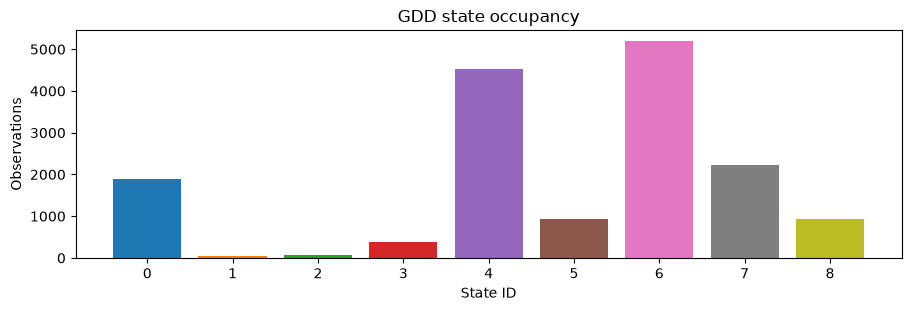

In [3]:
counts = state.group_by("Label").len(name="observations")
summary = segments.group_by("Label").agg(
    pl.len().alias("segments"), pl.col("samples").min().alias("min_samples"),
    pl.col("samples").median().alias("median_samples"),
    pl.col("samples").max().alias("max_samples"),
).join(counts,on="Label").with_columns(
    (pl.col("observations") / state.height * 100).alias("observation_percent"),
    (pl.col("median_samples") * median_dt).alias("approx_median_seconds"),
).sort("Label")
display(summary)
fig, ax = plt.subplots(figsize=(9,3), layout="constrained")
ax.bar(summary["Label"], summary["observations"], color=plt.get_cmap("tab10")(np.arange(summary.height)))
ax.set(xlabel="State ID", ylabel="Observations", title="GDD state occupancy", xticks=summary["Label"].to_list())
plt.show()


## State switching and waveforms

Colors identify categorical states; they do not encode severity or distance.
The first view shows the complete recording. The second shows the first 800
samples (about 38 seconds using the median interval). Adjust START and STOP.
All values are shown in source units, which are not verified physical units.


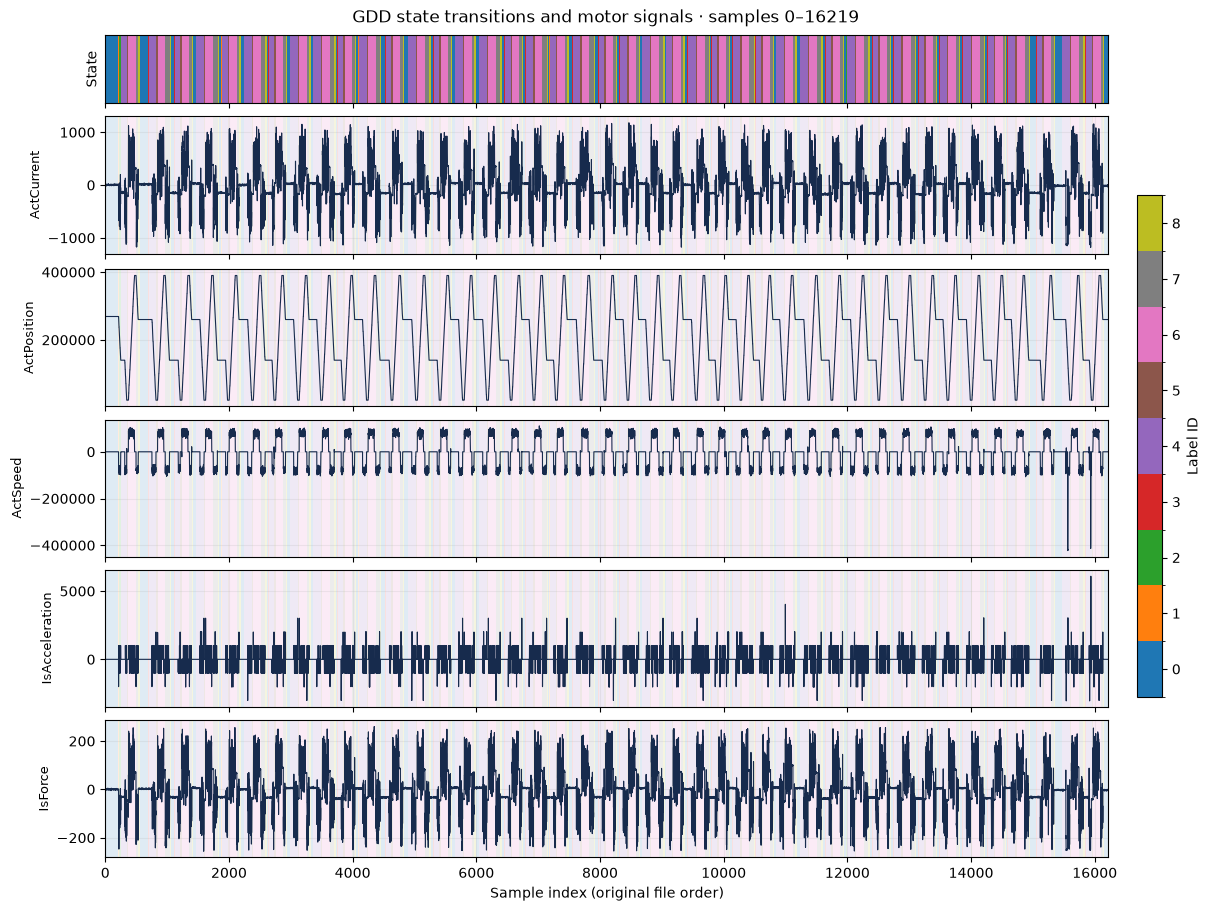

In [4]:
overview = plot_states(state, start=0, stop=state.height)
plt.show()


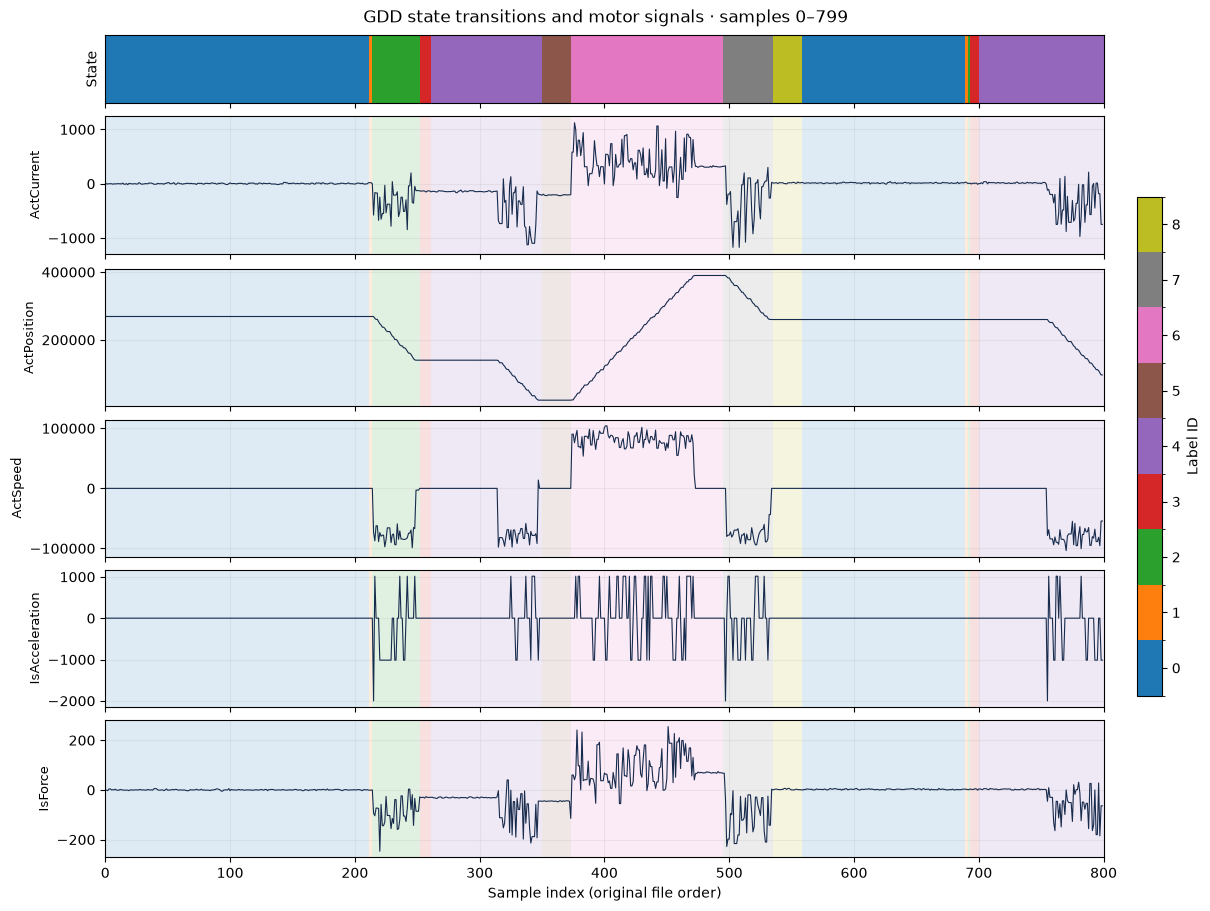

In [5]:
START, STOP = 0, 800
zoom = plot_states(state, start=START, stop=STOP)
plt.show()


## Empirical signal profiles by state

Compare motor-signal medians and binary flag activation fractions. Fractions near
one mean that a flag is usually active in that labeled state. These summaries
help interpret the IDs without assigning unverified action names.


Label,MotorData.ActCurrent,MotorData.ActPosition,MotorData.ActSpeed,MotorData.IsAcceleration,MotorData.IsForce
i64,f64,f64,f64,f64,f64
0,0.0,260014.0,0.0,0.0,0.0
1,-12.0,260014.0,0.0,0.0,-1.0
2,-148.0,224431.0,0.0,0.0,-33.0
3,-7.0,260014.0,0.0,0.0,0.0
4,-152.0,140012.0,0.0,0.0,-33.0
5,-182.0,22011.0,0.0,0.0,-40.0
6,362.0,246181.0,75284.0,0.0,81.0
7,-302.0,298381.0,-76850.0,0.0,-70.0
8,4.0,260014.0,0.0,0.0,0.0


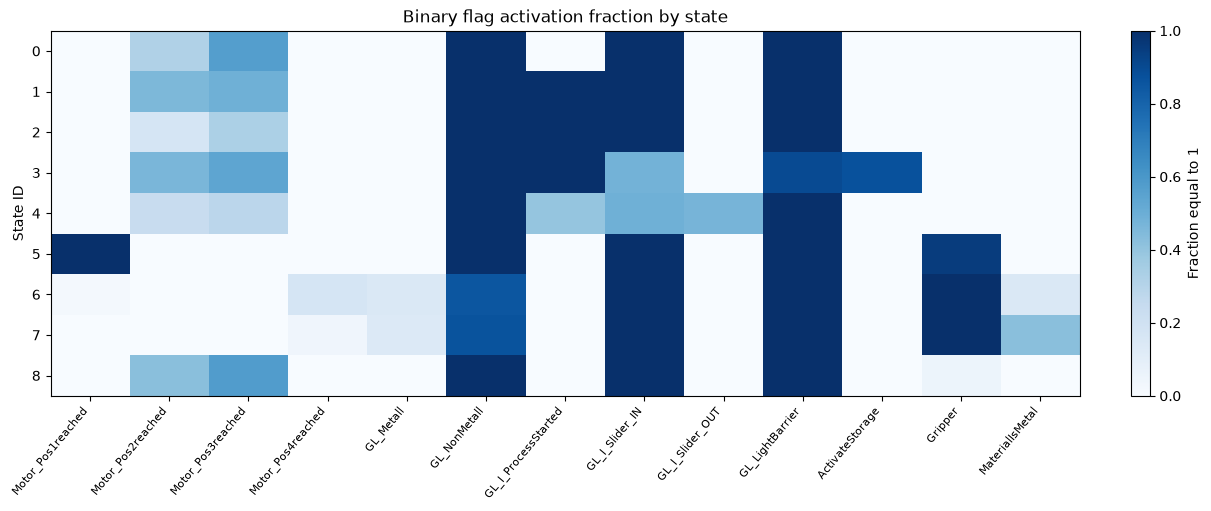

In [6]:
motor_profile = state.group_by("Label").agg(pl.col(MOTOR_SIGNALS).median()).sort("Label")
display(motor_profile)
binary = [c for c in state.columns if c not in {"Timestamp", "Label"}
          and set(state[c].drop_nulls().unique().to_list()) <= {0,1}]
flags = state.group_by("Label").agg(pl.col(binary).mean()).sort("Label")
fig, ax = plt.subplots(figsize=(12,5),layout="constrained")
image = ax.imshow(flags.select(binary).to_numpy(),vmin=0,vmax=1,cmap="Blues",aspect="auto")
ax.set_yticks(range(flags.height),labels=flags["Label"].to_list())
ax.set_xticks(range(len(binary)),labels=[c.split(".")[-1] for c in binary],rotation=50,ha="right",fontsize=8)
ax.set(ylabel="State ID",title="Binary flag activation fraction by state")
fig.colorbar(image,ax=ax,label="Fraction equal to 1")
plt.show()


## Transitions between segments

Counts below exclude self-transitions within a segment. They describe observed
order, not a causal graph or a complete specification of the PLC state machine.


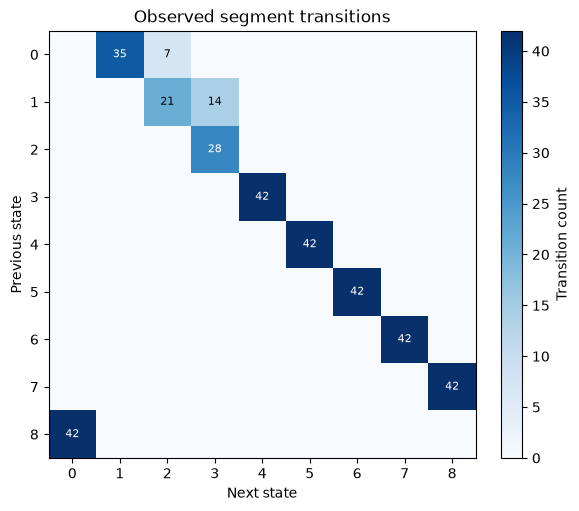

In [7]:
ids = sorted(state["Label"].unique().to_list())
index = {v:i for i,v in enumerate(ids)}
transition_counts = np.zeros((len(ids),len(ids)),dtype=int)
sequence = segments["Label"].to_list()
for a,b in zip(sequence,sequence[1:]):
    transition_counts[index[a],index[b]] += 1
fig, ax = plt.subplots(figsize=(6,5),layout="constrained")
image = ax.imshow(transition_counts,cmap="Blues")
for i in range(len(ids)):
    for j in range(len(ids)):
        if transition_counts[i,j]:
            ax.text(j,i,str(transition_counts[i,j]),ha="center",va="center",fontsize=8,
                    color="white" if transition_counts[i,j] > transition_counts.max()/2 else "black")
ax.set(xticks=range(len(ids)),yticks=range(len(ids)),xticklabels=ids,yticklabels=ids,
       xlabel="Next state",ylabel="Previous state",title="Observed segment transitions")
fig.colorbar(image,ax=ax,label="Transition count")
plt.show()


## Machine state is not an anomaly label

The two labeled CSVs contain the same observations with different targets.
State IDs describe operating states; anomaly IDs belong to a separate labeling
scheme. Do not treat state ID 0 as normal and all other state IDs as faults.


In [8]:
display(state.select(pl.col("Label").alias("state_id"))
        .with_columns(anomaly["Label"].alias("anomaly_id"))
        .group_by("state_id","anomaly_id").len().sort("state_id","anomaly_id"))


state_id,anomaly_id,len
i64,i64,u32
0,0,1882
1,0,55
2,0,76
3,0,383
4,0,4468
…,…,…
4,2,11
5,0,942
6,0,5193


## Implications for dependency-based segmentation

- Start with the five motor signals; inspect their distributions and near-constant
  intervals before fitting a Gaussian graphical model.
- Keep state and anomaly labels outside the input features. Binary control flags
  provide useful interpretation but can make segmentation much easier; evaluate
  their inclusion separately.
- Fit scaling and select hyperparameters using training blocks only. Use blocked
  temporal splits with a gap at least as large as the overlapping window span.
- Compare multi-scale representations against single-scale and mean/variance
  baselines. Report boundary accuracy as well as state agreement.
- Account for timestamp reversals and irregular intervals before making claims
  about physical time scales. Short states may not contain enough effectively
  independent observations to estimate a reliable local precision matrix.
- This notebook explores one recording, not independent experimental replicates.
